# 18 — Threshold Explícito, Curva de Decisão e Robustez

## Objetivo

Auditar controle explícito de threshold e robustez econômica/modelo para a referência e para os
candidatos calibrados já testados.

Este notebook parte das evidências do notebook 17:

- XGBoost, LightGBM e CatBoost já foram testados, além de RandomForest;
- melhor média econômica: `multijanela_core_ids_textual + CatBoost`;
- baseline simples competitivo: `referencia_24h_ids_textual + RandomForest`;
- nenhum algoritmo venceu todos os splits.

Mantém constantes:

- target: episódio futuro `Is_Dont_Go`;
- limpeza analítica;
- gap 900s;
- observação 24h;
- horizonte 8h;
- calibração sigmoide;
- função econômica com `p_acao_confirmada = 0,655` para caminhões.

## Splits temporais

Foram usados três cortes rolantes:

| Split | Treino base | Calibração | Threshold | Teste |
|---|---|---|---|---|
| S1 | jan | fev | mar | abr |
| S2 | jan-fev | mar | abr | mai |
| S3 | jan-mar | abr | mai | jun |

## Controle de vazamento

O vocabulário de IDs e conceitos é selecionado apenas em janeiro, o menor período de treino. Isso é
conservador para S2/S3, mas garante que nenhum mês futuro entre na seleção de features.

## Limites

- comparação econômica ainda é simulação, não ROI observado;
- `Manutenção` é proxy para `p_acao_confirmada`, não causalidade;
- hiperparâmetros são conservadores e fixos, sem tuning por teste.
- escavadeiras são avaliadas como recorte; um modelo separado só deve ser defendido se houver volume
  e estabilidade suficientes.

In [1]:
from pathlib import Path
import re
import time
import unicodedata
import warnings

import catboost as cb
import duckdb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, brier_score_loss,
    fbeta_score, precision_score, recall_score, roc_auc_score,
)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

GAP_S = 900
OBSERVATION_HOURS = 24
HORIZON_HOURS = 8
BUCKET_HOURS = 8
TOP_ALARM_IDS = 200
TOP_TEXT_CONCEPTS = 200
VOCAB_CUTOFF = "2025-02-01 00:00:00"
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")
THRESHOLD_GRID = np.round(np.linspace(0.01, 0.99, 197), 3)

economic_base = pd.DataFrame([
    {
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.655,
        "custo_intervencao_preditiva": 10000.0,
        "custo_manutencao_corretiva": 50000.0,
        "impacto_operacional_hora": 30000.0,
        "horas_parada_corretiva": 4.0,
        "horas_parada_preditiva": 1.0,
    },
    {
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.20,
        "custo_intervencao_preditiva": 25000.0,
        "custo_manutencao_corretiva": 150000.0,
        "impacto_operacional_hora": 100000.0,
        "horas_parada_corretiva": 8.0,
        "horas_parada_preditiva": 2.0,
    },
])

SPLITS = [
    {
        "split_id": "S1_teste_abril",
        "treino_fim": pd.Timestamp("2025-02-01"),
        "cal_inicio": pd.Timestamp("2025-02-01"),
        "cal_fim": pd.Timestamp("2025-03-01"),
        "val_inicio": pd.Timestamp("2025-03-01"),
        "val_fim": pd.Timestamp("2025-04-01"),
        "test_inicio": pd.Timestamp("2025-04-01"),
        "test_fim": pd.Timestamp("2025-05-01"),
    },
    {
        "split_id": "S2_teste_maio",
        "treino_fim": pd.Timestamp("2025-03-01"),
        "cal_inicio": pd.Timestamp("2025-03-01"),
        "cal_fim": pd.Timestamp("2025-04-01"),
        "val_inicio": pd.Timestamp("2025-04-01"),
        "val_fim": pd.Timestamp("2025-05-01"),
        "test_inicio": pd.Timestamp("2025-05-01"),
        "test_fim": pd.Timestamp("2025-05-31"),
    },
    {
        "split_id": "S3_teste_junho",
        "treino_fim": pd.Timestamp("2025-04-01"),
        "cal_inicio": pd.Timestamp("2025-04-01"),
        "cal_fim": pd.Timestamp("2025-05-01"),
        "val_inicio": pd.Timestamp("2025-05-01"),
        "val_fim": pd.Timestamp("2025-05-31"),
        "test_inicio": pd.Timestamp("2025-06-01"),
        "test_fim": pd.Timestamp("2025-07-01"),
    },
]

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

def normalize_tipo(value):
    if pd.isna(value):
        return "Indefinido"
    return "Escavadeira" if "ESCAV" in str(value).upper() else "Caminhao"

print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: /home/f_szekut/projects/vale_correct


## 1. Preparação da base e features

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_sequences AS
    WITH ordered AS (
        SELECT *,
               lag(Data_Evento) OVER (
                   PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
               ) AS evento_anterior
        FROM analytic_events
    ), flagged AS (
        SELECT *,
               CASE
                   WHEN evento_anterior IS NULL THEN 1
                   WHEN date_diff('millisecond', evento_anterior, Data_Evento) > {GAP_S * 1000} THEN 1
                   ELSE 0
               END AS nova_sequencia
        FROM ordered
    ), numbered AS (
        SELECT *,
               sum(nova_sequencia) OVER (
                   PARTITION BY TAG, Id_Alarme
                   ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) AS numero_sequencia
        FROM flagged
    )
    SELECT
        TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
        Id_Alarme, any_value(Alarme) AS Alarme,
        numero_sequencia,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim,
        time_bucket(INTERVAL '8 hours', min(Data_Evento)) AS bin_start,
        date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo) AS registros_brutos_representados,
        max(Is_Dont_Go) AS is_dont_go,
        max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
        max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
        max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
        max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
    FROM numbered
    GROUP BY TAG, Id_Alarme, numero_sequencia
    '''
)

base_audit = query(
    '''
    SELECT
        (SELECT count(*) FROM analytic_events) AS registros_analiticos,
        (SELECT sum(ids_evento_no_grupo - 1) FROM analytic_events) AS duplicatas_retiradas,
        count(*) AS sequencias,
        sum(is_dont_go) AS sequencias_dont_go
    FROM alarm_sequences
    '''
)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,sequencias,sequencias_dont_go
0,35608094,265564.0,979994,7572.0


In [3]:
catalog = query(
    '''
    SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias
    FROM alarm_sequences
    GROUP BY 1
    ORDER BY sequencias DESC
    '''
)
catalog["conceito_textual"] = catalog["Alarme"].map(normalize_alarm_name)
con.register("alarm_concepts", catalog[["Id_Alarme", "conceito_textual"]])

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE sample_grid AS
    WITH tags AS (
        SELECT DISTINCT TAG FROM analytic_events
    ), prediction_bins AS (
        SELECT * FROM generate_series(
            TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{OBSERVATION_HOURS} hours',
            TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{HORIZON_HOURS} hours',
            INTERVAL '8 hours'
        ) AS t(prediction_time)
    )
    SELECT
        row_number() OVER () AS sample_id,
        tags.TAG,
        prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' AS feature_start,
        prediction_time,
        prediction_time + INTERVAL '{HORIZON_HOURS} hours' AS target_end
    FROM tags CROSS JOIN prediction_bins
    WHERE prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' >= TIMESTAMP '2025-01-01 00:00:00'
    '''
)

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sequence_bins AS
    SELECT
        TAG, bin_start,
        count(*) AS sequencias_total,
        count(DISTINCT Id_Alarme) AS alarmes_distintos,
        sum(registros_analiticos) AS registros_analiticos,
        sum(registros_brutos_representados) AS registros_brutos_representados,
        sum(duracao_ms) AS duracao_soma_ms,
        max(duracao_ms) AS duracao_max_ms,
        max(registros_analiticos) AS maior_sequencia_registros,
        sum(possui_critico) AS sequencias_com_critico,
        sum(possui_activate) AS sequencias_com_activate,
        sum(possui_inactive) AS sequencias_com_inactive,
        sum(possui_classe_nula) AS sequencias_com_classe_nula,
        sum(is_dont_go) AS episodios_dont_go
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)

In [4]:
samples = query(
    f'''
    WITH feature_agg AS (
        SELECT
            g.sample_id,
            coalesce(sum(b.sequencias_total), 0) AS sequencias_total,
            coalesce(sum(b.alarmes_distintos), 0) AS alarmes_distintos,
            coalesce(sum(b.registros_analiticos), 0) AS registros_analiticos,
            coalesce(sum(b.registros_brutos_representados), 0) AS registros_brutos_representados,
            CASE
                WHEN coalesce(sum(b.sequencias_total), 0) > 0
                THEN coalesce(sum(b.duracao_soma_ms), 0) / sum(b.sequencias_total)
                ELSE 0
            END AS duracao_media_ms,
            coalesce(max(b.duracao_max_ms), 0) AS duracao_max_ms,
            coalesce(max(b.maior_sequencia_registros), 0) AS maior_sequencia_registros,
            coalesce(sum(b.sequencias_com_critico), 0) AS sequencias_com_critico,
            coalesce(sum(b.sequencias_com_activate), 0) AS sequencias_com_activate,
            coalesce(sum(b.sequencias_com_inactive), 0) AS sequencias_com_inactive,
            coalesce(sum(b.sequencias_com_classe_nula), 0) AS sequencias_com_classe_nula
        FROM sample_grid g
        LEFT JOIN sequence_bins b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
    ), target_agg AS (
        SELECT
            g.sample_id,
            coalesce(sum(b.episodios_dont_go), 0) AS episodios_dont_go_target
        FROM sample_grid g
        LEFT JOIN sequence_bins b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.prediction_time
         AND b.bin_start < g.target_end
        GROUP BY 1
    )
    SELECT
        g.sample_id, g.TAG, g.feature_start, g.prediction_time, g.target_end,
        f.* EXCLUDE(sample_id),
        y.episodios_dont_go_target,
        CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
        CASE
            WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
             AND g.target_end > TIMESTAMP '{MISSING_START}'
            THEN 0 ELSE 1
        END AS amostra_valida
    FROM sample_grid g
    JOIN feature_agg f USING(sample_id)
    JOIN target_agg y USING(sample_id)
    ORDER BY g.prediction_time, g.TAG
    '''
)
samples = samples[samples["amostra_valida"] == 1].copy()
tag_profile = query(
    '''
    SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
    FROM analytic_events
    GROUP BY 1
    '''
)
samples = samples.merge(tag_profile, how="left", on="TAG")
samples["Tipo"] = samples["Tipo"].replace({"Caminhão": "Caminhao"})

base_derived = pd.DataFrame({
    "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
    "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
    "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
    "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
    "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
}, index=samples.index)
samples = pd.concat([samples, base_derived], axis=1).copy()

base_features = [
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
    "maior_sequencia_registros", "sequencias_com_critico",
    "sequencias_com_activate", "sequencias_com_inactive",
    "sequencias_com_classe_nula", "feature_has_events",
    "prediction_hour_sin", "prediction_hour_cos", "prediction_dow_sin", "prediction_dow_cos",
]
display(samples.groupby(samples["prediction_time"].dt.to_period("M")).agg(
    amostras=("target", "size"),
    positivas=("target", "sum"),
    prevalencia=("target", "mean"),
).reset_index())

,prediction_time,amostras,positivas,prevalencia
0,2025-01,3150,469,0.148889
1,2025-02,2940,566,0.192517
2,2025-03,3255,511,0.156989
3,2025-04,3150,364,0.115556
4,2025-05,3150,287,0.091111
5,2025-06,3045,285,0.093596


In [5]:
top_ids = query(
    f'''
    SELECT Id_Alarme, count(*) AS sequencias
    FROM alarm_sequences
    WHERE inicio < TIMESTAMP '{VOCAB_CUTOFF}'
    GROUP BY 1
    ORDER BY sequencias DESC, Id_Alarme
    LIMIT {TOP_ALARM_IDS}
    '''
)["Id_Alarme"].astype(int).tolist()

id_expr = ",\n".join(
    f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
    for alarm_id in top_ids
)
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_bin_features AS
    SELECT TAG, bin_start, {id_expr}
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)
id_sum_expr = ", ".join(
    f"coalesce(sum(b.alarm_{alarm_id}), 0) AS alarm_{alarm_id}" for alarm_id in top_ids
)
id_wide = query(
    f'''
    SELECT g.sample_id, {id_sum_expr}
    FROM sample_grid g
    LEFT JOIN alarm_bin_features b
      ON b.TAG = g.TAG
     AND b.bin_start >= g.feature_start
     AND b.bin_start < g.prediction_time
    GROUP BY 1
    '''
)
id_features = [f"alarm_{alarm_id}" for alarm_id in top_ids]
samples = samples.merge(id_wide, how="left", on="sample_id")
samples[id_features] = samples[id_features].fillna(0).astype("int32")

top_text = query(
    f'''
    SELECT c.conceito_textual AS valor, count(*) AS sequencias
    FROM alarm_sequences s
    JOIN alarm_concepts c USING(Id_Alarme)
    WHERE s.inicio < TIMESTAMP '{VOCAB_CUTOFF}'
    GROUP BY 1
    ORDER BY sequencias DESC, valor
    LIMIT {TOP_TEXT_CONCEPTS}
    '''
)
text_values = top_text["valor"].tolist()
text_name_map = {value: f"textconcept_{i:03d}" for i, value in enumerate(text_values)}
def sql_literal(value):
    return "'" + str(value).replace("'", "''") + "'"
text_expr = ",\n".join(
    f"sum(CASE WHEN c.conceito_textual = {sql_literal(value)} THEN 1 ELSE 0 END) AS {text_name_map[value]}"
    for value in text_values
)
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE text_bin_features AS
    SELECT s.TAG, s.bin_start, {text_expr}
    FROM alarm_sequences s
    LEFT JOIN alarm_concepts c USING(Id_Alarme)
    GROUP BY 1, 2
    '''
)
text_sum_expr = ", ".join(
    f"coalesce(sum(b.{text_name_map[value]}), 0) AS {text_name_map[value]}" for value in text_values
)
text_wide = query(
    f'''
    SELECT g.sample_id, {text_sum_expr}
    FROM sample_grid g
    LEFT JOIN text_bin_features b
      ON b.TAG = g.TAG
     AND b.bin_start >= g.feature_start
     AND b.bin_start < g.prediction_time
    GROUP BY 1
    '''
)
text_features = [text_name_map[value] for value in text_values]
samples = samples.merge(text_wide, how="left", on="sample_id")
samples[text_features] = samples[text_features].fillna(0).astype("int32")

print(f"Vocabulário conservador de janeiro: {len(id_features)} IDs, {len(text_features)} conceitos")

Vocabulário conservador de janeiro: 200 IDs, 200 conceitos


In [6]:
core_cols = [
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "registros_brutos_representados", "duracao_soma_ms", "duracao_max_ms",
    "maior_sequencia_registros", "sequencias_com_critico",
    "sequencias_com_activate", "sequencias_com_inactive", "sequencias_com_classe_nula",
]
select_parts = []
for bucket_idx in range(3):
    start_h = bucket_idx * BUCKET_HOURS
    end_h = (bucket_idx + 1) * BUCKET_HOURS
    suffix = f"b{bucket_idx}_{start_h}_{end_h}h"
    for col in core_cols:
        select_parts.append(
            f"coalesce(sum(CASE WHEN b.bin_start >= g.prediction_time - INTERVAL '{end_h} hours' "
            f"AND b.bin_start < g.prediction_time - INTERVAL '{start_h} hours' "
            f"THEN b.{col} ELSE 0 END), 0) AS {col}_{suffix}"
        )
bucket_wide = query(
    f'''
    SELECT g.sample_id,
           {", ".join(select_parts)}
    FROM sample_grid g
    LEFT JOIN sequence_bins b
      ON b.TAG = g.TAG
     AND b.bin_start >= g.feature_start
     AND b.bin_start < g.prediction_time
    GROUP BY 1
    '''
)
bucket_features = [c for c in bucket_wide.columns if c != "sample_id"]
samples = samples.merge(bucket_wide, how="left", on="sample_id")
samples[bucket_features] = samples[bucket_features].fillna(0).astype("float32")

derived = {}
derived_features = []
for base in ["sequencias_total", "alarmes_distintos", "registros_analiticos", "sequencias_com_critico"]:
    recent = f"{base}_b0_0_8h"
    middle = f"{base}_b1_8_16h"
    old = f"{base}_b2_16_24h"
    delta = f"{base}_delta_recent_old"
    ratio = f"{base}_ratio_recent_total"
    derived[delta] = samples[recent] - samples[old]
    derived[ratio] = samples[recent] / (samples[recent] + samples[middle] + samples[old] + 1)
    derived_features.extend([delta, ratio])
samples = pd.concat([samples, pd.DataFrame(derived, index=samples.index)], axis=1).copy()
core_bucket_features = bucket_features + derived_features

FEATURE_SETS = {
    "referencia_24h_ids_textual": base_features + id_features + text_features,
    "multijanela_core_ids_textual": core_bucket_features + id_features + text_features,
}
print({k: len(v) for k, v in FEATURE_SETS.items()})
print(f"Preparação total: {time.time() - start:.1f}s")

{'referencia_24h_ids_textual': 416, 'multijanela_core_ids_textual': 441}
Preparação total: 85.3s


## 2. Treino, calibração sigmoide e thresholds econômicos

In [7]:
def assign_periods(df, split_cfg):
    out = df.copy()
    pt = out["prediction_time"]
    out["periodo"] = np.select(
        [
            pt < split_cfg["treino_fim"],
            (pt >= split_cfg["cal_inicio"]) & (pt < split_cfg["cal_fim"]),
            (pt >= split_cfg["val_inicio"]) & (pt < split_cfg["val_fim"]),
            (pt >= split_cfg["test_inicio"]) & (pt < split_cfg["test_fim"]),
        ],
        ["treino_base", "calibracao", "validacao", "teste"],
        default="fora",
    )
    return out[out["periodo"] != "fora"].copy()

def make_model(name, y_train):
    pos = max(float(y_train.sum()), 1.0)
    neg = max(float(len(y_train) - y_train.sum()), 1.0)
    scale_pos_weight = neg / pos
    if name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=300, max_features="sqrt", min_samples_leaf=2,
            class_weight="balanced_subsample", random_state=42, n_jobs=-1
        )
    if name == "XGBoost":
        return xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9,
            colsample_bytree=0.8, min_child_weight=5, reg_lambda=2.0,
            objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1,
        )
    if name == "LightGBM":
        return lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=31,
            min_child_samples=40, subsample=0.9, colsample_bytree=0.8,
            reg_lambda=2.0, class_weight="balanced", random_state=42,
            n_jobs=-1, verbose=-1,
        )
    if name == "CatBoost":
        return cb.CatBoostClassifier(
            iterations=300, depth=5, learning_rate=0.05,
            loss_function="Logloss", eval_metric="Logloss",
            auto_class_weights="Balanced", random_seed=42,
            verbose=False, allow_writing_files=False,
        )
    raise ValueError(name)

def predict_proba(model, x_part):
    return model.predict_proba(x_part)[:, 1]

def economic_value_rows(pred_df, threshold):
    scored = pred_df.copy()
    econ_cols = [
        "p_acao_confirmada", "custo_intervencao_preditiva",
        "custo_manutencao_corretiva", "impacto_operacional_hora",
        "horas_parada_corretiva", "horas_parada_preditiva",
    ]
    scored = scored.drop(columns=[c for c in econ_cols if c in scored.columns])
    scored["predito"] = (scored["probabilidade"] >= threshold).astype("int8")
    scored["erro"] = np.select(
        [
            (scored["target"] == 1) & (scored["predito"] == 1),
            (scored["target"] == 0) & (scored["predito"] == 1),
            (scored["target"] == 1) & (scored["predito"] == 0),
            (scored["target"] == 0) & (scored["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    scored["tipo_economico"] = scored["Tipo"].map(normalize_tipo)
    scored = scored.merge(economic_base.rename(columns={"Tipo": "tipo_economico"}), how="left", on="tipo_economico")
    no_action_cost = scored["p_acao_confirmada"] * (
        scored["custo_manutencao_corretiva"]
        + scored["impacto_operacional_hora"] * scored["horas_parada_corretiva"]
    )
    tp_action_cost = scored["custo_intervencao_preditiva"] + scored["p_acao_confirmada"] * (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )
    fp_action_cost = scored["custo_intervencao_preditiva"] + (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )
    scored["valor_incremental"] = np.select(
        [
            scored["erro"] == "TP",
            scored["erro"] == "FP",
            scored["erro"] == "FN",
            scored["erro"] == "TN",
        ],
        [
            no_action_cost - tp_action_cost,
            -fp_action_cost,
            0.0,
            0.0,
        ],
        default=np.nan,
    )
    return scored

def metric_at_threshold(df, threshold):
    y = df["target"].astype("int8")
    p = df["probabilidade"].to_numpy()
    pred = (p >= threshold).astype("int8")
    scored = economic_value_rows(df, threshold)
    return {
        "threshold": threshold,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f2": fbeta_score(y, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "brier": brier_score_loss(y, p),
        "pr_auc": average_precision_score(y, p),
        "roc_auc": roc_auc_score(y, p),
        "TP": int(((y == 1) & (pred == 1)).sum()),
        "FP": int(((y == 0) & (pred == 1)).sum()),
        "FN": int(((y == 1) & (pred == 0)).sum()),
        "TN": int(((y == 0) & (pred == 0)).sum()),
        "predicoes_positivas": int(pred.sum()),
        "valor_incremental": scored["valor_incremental"].sum(),
    }

In [8]:
ALGORITHMS = ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]
all_results = []
all_predictions = []
all_threshold_curves = []

for split_cfg in SPLITS:
    split_samples = assign_periods(samples, split_cfg)
    split_audit = split_samples.groupby(["periodo", "Tipo"], dropna=False).agg(
        amostras=("target", "size"),
        positivas=("target", "sum"),
        prevalencia=("target", "mean"),
    ).reset_index()
    split_audit["split_id"] = split_cfg["split_id"]
    display(split_audit)
    for feature_name, feature_cols in FEATURE_SETS.items():
        for algo in ALGORITHMS:
            start_fit = time.time()
            train = split_samples[split_samples["periodo"] == "treino_base"]
            cal = split_samples[split_samples["periodo"] == "calibracao"]
            val = split_samples[split_samples["periodo"] == "validacao"]
            test = split_samples[split_samples["periodo"] == "teste"]
            x_train = train[feature_cols].astype("float32")
            y_train = train["target"].astype("int8")
            model = make_model(algo, y_train)
            model.fit(x_train, y_train)
            cal_raw = predict_proba(model, cal[feature_cols].astype("float32"))
            val_raw = predict_proba(model, val[feature_cols].astype("float32"))
            test_raw = predict_proba(model, test[feature_cols].astype("float32"))
            calibrator = LogisticRegression(solver="lbfgs")
            calibrator.fit(cal_raw.reshape(-1, 1), cal["target"].astype("int8"))
            frames = []
            for periodo, part, raw in [
                ("validacao", val, val_raw),
                ("teste", test, test_raw),
            ]:
                out = part[["sample_id", "TAG", "Tipo", "Tag_Frota", "prediction_time", "target"]].copy()
                out["split_id"] = split_cfg["split_id"]
                out["feature_set"] = feature_name
                out["algoritmo"] = algo
                out["periodo"] = periodo
                out["probabilidade"] = calibrator.predict_proba(raw.reshape(-1, 1))[:, 1]
                frames.append(out)
            pred_df = pd.concat(frames, ignore_index=True)
            rows = []
            for threshold in THRESHOLD_GRID:
                row = metric_at_threshold(pred_df[pred_df["periodo"] == "validacao"], threshold)
                row["threshold"] = threshold
                rows.append(row)
            val_thresholds = pd.DataFrame(rows)
            val_thresholds["split_id"] = split_cfg["split_id"]
            val_thresholds["feature_set"] = feature_name
            val_thresholds["algoritmo"] = algo
            val_thresholds["periodo"] = "validacao"
            all_threshold_curves.append(val_thresholds)
            best = val_thresholds.sort_values(["valor_incremental", "threshold"], ascending=[False, False]).iloc[0]
            test_rows = []
            for threshold in THRESHOLD_GRID:
                row = metric_at_threshold(pred_df[pred_df["periodo"] == "teste"], threshold)
                row["threshold"] = threshold
                test_rows.append(row)
            test_thresholds = pd.DataFrame(test_rows)
            test_thresholds["split_id"] = split_cfg["split_id"]
            test_thresholds["feature_set"] = feature_name
            test_thresholds["algoritmo"] = algo
            test_thresholds["periodo"] = "teste"
            all_threshold_curves.append(test_thresholds)
            test_metrics = metric_at_threshold(pred_df[pred_df["periodo"] == "teste"], float(best["threshold"]))
            result = {
                "split_id": split_cfg["split_id"],
                "feature_set": feature_name,
                "algoritmo": algo,
                "threshold_validacao": float(best["threshold"]),
                "valor_validacao": float(best["valor_incremental"]),
                "tempo_s": round(time.time() - start_fit, 1),
            }
            result.update({f"teste_{k}": v for k, v in test_metrics.items()})
            all_results.append(result)
            pred_test = economic_value_rows(pred_df[pred_df["periodo"] == "teste"], float(best["threshold"]))
            pred_test["threshold_validacao"] = float(best["threshold"])
            all_predictions.append(pred_test)
            print(split_cfg["split_id"], feature_name, algo, "valor_teste", round(test_metrics["valor_incremental"], 1))

results = pd.DataFrame(all_results)
predictions = pd.concat(all_predictions, ignore_index=True)
threshold_curves = pd.concat(all_threshold_curves, ignore_index=True)
display(results.sort_values("teste_valor_incremental", ascending=False).head(30))

,periodo,Tipo,amostras,positivas,prevalencia,split_id
0,calibracao,Caminhao,2520,560,0.222222,S1_teste_abril
1,calibracao,Escavadeira,420,6,0.014286,S1_teste_abril
2,teste,Caminhao,2700,363,0.134444,S1_teste_abril
3,teste,Escavadeira,450,1,0.002222,S1_teste_abril
4,treino_base,Caminhao,2700,462,0.171111,S1_teste_abril
5,treino_base,Escavadeira,450,7,0.015556,S1_teste_abril
6,validacao,Caminhao,2790,510,0.182796,S1_teste_abril
7,validacao,Escavadeira,465,1,0.002151,S1_teste_abril


S1_teste_abril referencia_24h_ids_textual RandomForest valor_teste 3025300.0


S1_teste_abril referencia_24h_ids_textual XGBoost valor_teste 1078100.0


S1_teste_abril referencia_24h_ids_textual LightGBM valor_teste 151000.0


S1_teste_abril referencia_24h_ids_textual CatBoost valor_teste 2038900.0


...

S3_teste_junho multijanela_core_ids_textual RandomForest valor_teste 2716500.0


S3_teste_junho multijanela_core_ids_textual XGBoost valor_teste 3260200.0


S3_teste_junho multijanela_core_ids_textual LightGBM valor_teste 3164100.0


S3_teste_junho multijanela_core_ids_textual CatBoost valor_teste 3184500.0


,split_id,feature_set,algoritmo,threshold_validacao,valor_validacao,tempo_s,teste_threshold,teste_precision,teste_recall,teste_f2,teste_balanced_accuracy,teste_brier,teste_pr_auc,teste_roc_auc,teste_TP,teste_FP,teste_FN,teste_TN,teste_predicoes_positivas,teste_valor_incremental
21,S3_teste_junho,multijanela_core_ids_textual,XGBoost,0.305,3138500.0,8.7,0.305,0.439834,0.371930,0.383780,0.661508,0.070653,0.378583,0.829650,106,135,179,2625,241,3260200.0
23,S3_teste_junho,multijanela_core_ids_textual,CatBoost,0.370,2850900.0,8.5,0.370,0.474860,0.298246,0.322214,0.632094,0.070691,0.370700,0.831861,85,94,200,2666,179,3184500.0
22,S3_teste_junho,multijanela_core_ids_textual,LightGBM,0.385,2085800.0,8.4,0.385,0.510490,0.256140,0.284489,0.615389,0.072634,0.350226,0.807132,73,70,212,2690,143,3164100.0
0,S1_teste_abril,referencia_24h_ids_textual,RandomForest,0.335,8945100.0,9.2,0.335,0.425781,0.299451,0.318341,0.623343,0.092323,0.310293,0.759089,109,147,255,2639,256,3025300.0
20,S3_teste_junho,multijanela_core_ids_textual,RandomForest,0.495,2031400.0,9.4,0.495,0.652174,0.157895,0.186104,0.574600,0.071691,0.359497,0.825717,45,24,240,2736,69,2716500.0
19,S3_teste_junho,referencia_24h_ids_textual,CatBoost,0.350,2134300.0,8.6,0.350,0.425234,0.319298,0.336041,0.637367,0.072109,0.354940,0.817999,91,123,194,2637,214,2514700.0
7,S1_teste_abril,multijanela_core_ids_textual,CatBoost,0.380,7010700.0,8.2,0.380,0.413934,0.277473,0.297059,0.613072,0.092837,0.311171,0.762942,101,143,263,2643,244,2346700.0
17,S3_teste_junho,referencia_24h_ids_textual,XGBoost,0.325,2313000.0,9.0,0.325,0.412322,0.305263,0.321984,0.630168,0.072615,0.345648,0.813290,87,124,198,2636,211,2147900.0
16,S3_teste_junho,referencia_24h_ids_textual,RandomForest,0.410,1650100.0,10.0,0.410,0.490385,0.178947,0.204984,0.579872,0.073580,0.326442,0.815207,51,53,234,2707,104,2046700.0
3,S1_teste_abril,referencia_24h_ids_textual,CatBoost,0.320,5429400.0,8.1,0.320,0.383607,0.321429,0.332198,0.626974,0.093241,0.297044,0.751865,117,188,247,2598,305,2038900.0


## 3. Consolidação dos resultados

In [9]:
rank_by_split = (
    results.sort_values(["split_id", "teste_valor_incremental"], ascending=[True, False])
    .groupby("split_id")
    .head(10)
)
display(rank_by_split[[
    "split_id", "feature_set", "algoritmo", "threshold_validacao",
    "teste_valor_incremental", "teste_precision", "teste_recall",
    "teste_TP", "teste_FP", "teste_FN", "teste_brier", "teste_pr_auc", "tempo_s"
]])

summary = (
    results.groupby(["feature_set", "algoritmo"])
    .agg(
        splits=("split_id", "nunique"),
        valor_medio=("teste_valor_incremental", "mean"),
        valor_mediano=("teste_valor_incremental", "median"),
        valor_min=("teste_valor_incremental", "min"),
        valor_max=("teste_valor_incremental", "max"),
        precision_media=("teste_precision", "mean"),
        recall_media=("teste_recall", "mean"),
        fp_medio=("teste_FP", "mean"),
        fn_medio=("teste_FN", "mean"),
        brier_medio=("teste_brier", "mean"),
        pr_auc_medio=("teste_pr_auc", "mean"),
        tempo_medio_s=("tempo_s", "mean"),
    )
    .reset_index()
    .sort_values("valor_medio", ascending=False)
)
display(summary)

winners = (
    results.sort_values(["split_id", "teste_valor_incremental"], ascending=[True, False])
    .groupby("split_id")
    .head(1)
    [["split_id", "feature_set", "algoritmo", "teste_valor_incremental"]]
)
display(winners)

,split_id,feature_set,algoritmo,threshold_validacao,teste_valor_incremental,teste_precision,teste_recall,teste_TP,teste_FP,teste_FN,teste_brier,teste_pr_auc,tempo_s
0,S1_teste_abril,referencia_24h_ids_textual,RandomForest,0.335,3025300.0,0.425781,0.299451,109,147,255,0.092323,0.310293,9.2
7,S1_teste_abril,multijanela_core_ids_textual,CatBoost,0.380,2346700.0,0.413934,0.277473,101,143,263,0.092837,0.311171,8.2
3,S1_teste_abril,referencia_24h_ids_textual,CatBoost,0.320,2038900.0,0.383607,0.321429,117,188,247,0.093241,0.297044,8.1
4,S1_teste_abril,multijanela_core_ids_textual,RandomForest,0.220,1288200.0,0.354369,0.401099,146,266,218,0.091504,0.323304,8.9
6,S1_teste_abril,multijanela_core_ids_textual,LightGBM,0.235,1116800.0,0.385185,0.285714,104,166,260,0.095224,0.276253,8.0
1,S1_teste_abril,referencia_24h_ids_textual,XGBoost,0.330,1078100.0,0.363281,0.255495,93,163,271,0.096683,0.260439,8.5
5,S1_teste_abril,multijanela_core_ids_textual,XGBoost,0.295,581600.0,0.351254,0.269231,98,181,266,0.095033,0.278328,8.2
2,S1_teste_abril,referencia_24h_ids_textual,LightGBM,0.300,151000.0,0.340426,0.219780,80,155,284,0.097286,0.263919,7.9
13,S2_teste_maio,multijanela_core_ids_textual,XGBoost,0.480,1900300.0,0.446970,0.205575,59,73,228,0.075207,0.302595,9.2
12,S2_teste_maio,multijanela_core_ids_textual,RandomForest,0.360,1889200.0,0.413043,0.264808,76,108,211,0.075571,0.297033,9.7


,feature_set,algoritmo,splits,valor_medio,valor_mediano,valor_min,valor_max,precision_media,recall_media,fp_medio,fn_medio,brier_medio,pr_auc_medio,tempo_medio_s
0,multijanela_core_ids_textual,CatBoost,3,2.294733e+06,2346700.0,1353000.0,3184500.0,0.421265,0.296436,129.000000,220.000000,0.079555,0.327143,8.500000
6,referencia_24h_ids_textual,RandomForest,3,2.100833e+06,2046700.0,1230500.0,3025300.0,0.435129,0.234960,100.666667,237.000000,0.081155,0.301095,9.566667
2,multijanela_core_ids_textual,RandomForest,3,1.964633e+06,1889200.0,1288200.0,2716500.0,0.473195,0.274601,132.666667,223.000000,0.079589,0.326611,9.333333
4,referencia_24h_ids_textual,CatBoost,3,1.916400e+06,2038900.0,1195600.0,2514700.0,0.397674,0.292554,140.000000,220.000000,0.080461,0.313226,8.466667
3,multijanela_core_ids_textual,XGBoost,3,1.914033e+06,1900300.0,581600.0,3260200.0,0.412686,0.282245,129.666667,224.333333,0.080298,0.319835,8.700000
1,multijanela_core_ids_textual,LightGBM,3,1.843100e+06,1248400.0,1116800.0,3164100.0,0.435041,0.241013,103.666667,235.666667,0.082083,0.298579,8.333333
7,referencia_24h_ids_textual,XGBoost,3,1.083500e+06,1078100.0,24500.0,2147900.0,0.368354,0.285642,153.333333,223.666667,0.082048,0.300332,8.700000
5,referencia_24h_ids_textual,LightGBM,3,1.501000e+05,151000.0,111400.0,187900.0,0.337014,0.223795,137.000000,242.333333,0.084020,0.265758,8.233333


,split_id,feature_set,algoritmo,teste_valor_incremental
0,S1_teste_abril,referencia_24h_ids_textual,RandomForest,3025300.0
13,S2_teste_maio,multijanela_core_ids_textual,XGBoost,1900300.0
21,S3_teste_junho,multijanela_core_ids_textual,XGBoost,3260200.0


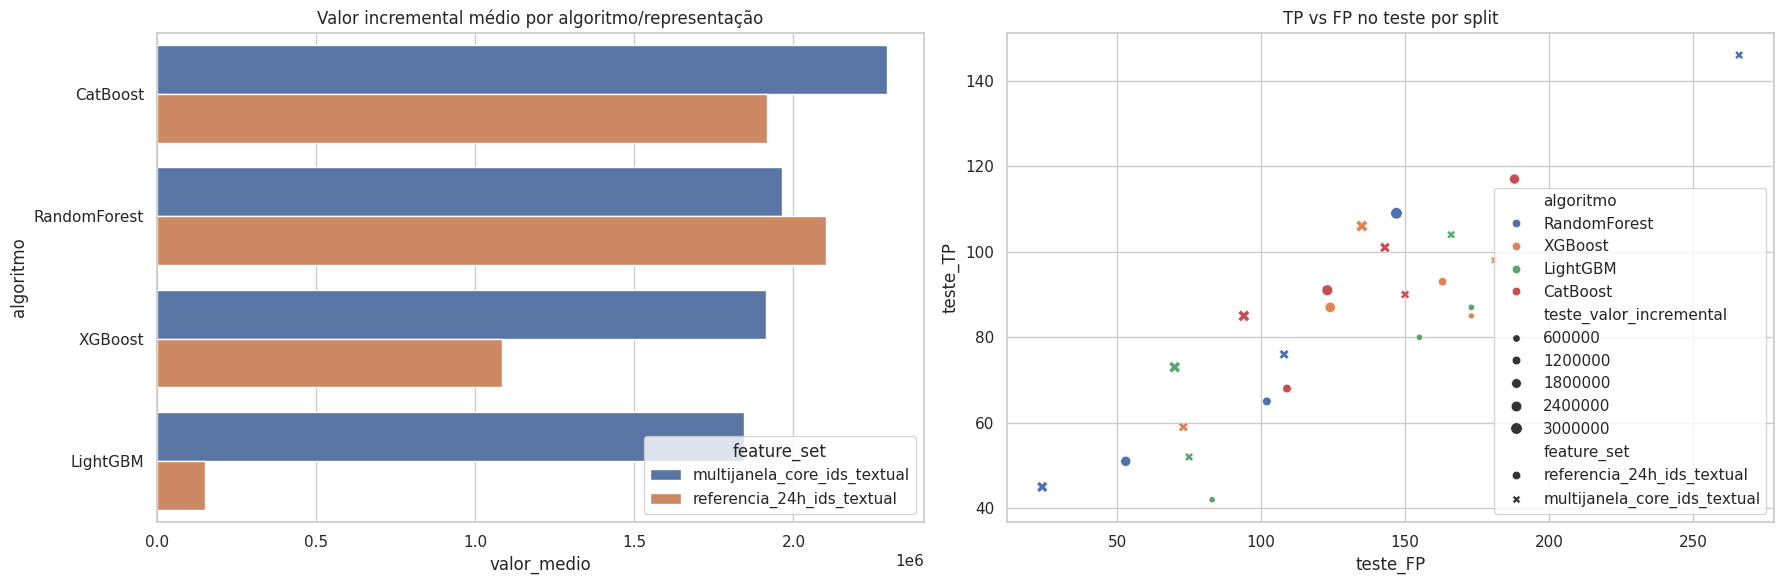

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=summary, y="algoritmo", x="valor_medio", hue="feature_set", ax=axes[0])
axes[0].set(title="Valor incremental médio por algoritmo/representação")
sns.scatterplot(data=results, x="teste_FP", y="teste_TP", hue="algoritmo", style="feature_set", size="teste_valor_incremental", ax=axes[1])
axes[1].set(title="TP vs FP no teste por split")
plt.tight_layout()
plt.show()

## 4. Recortes do melhor candidato

In [11]:
best_combo = summary.iloc[0][["feature_set", "algoritmo"]].to_dict()
print("Melhor combinação por valor médio:", best_combo)
best_predictions = predictions[
    (predictions["feature_set"] == best_combo["feature_set"])
    & (predictions["algoritmo"] == best_combo["algoritmo"])
].copy()

type_summary = (
    best_predictions.groupby(["split_id", "Tipo"], dropna=False)
    .agg(
        amostras=("target", "size"),
        positivos=("target", "sum"),
        preditos=("predito", "sum"),
        TP=("erro", lambda x: (x == "TP").sum()),
        FP=("erro", lambda x: (x == "FP").sum()),
        FN=("erro", lambda x: (x == "FN").sum()),
        TN=("erro", lambda x: (x == "TN").sum()),
        valor=("valor_incremental", "sum"),
    )
    .reset_index()
)
type_summary["precision"] = type_summary["TP"] / (type_summary["TP"] + type_summary["FP"]).replace(0, np.nan)
type_summary["recall"] = type_summary["TP"] / (type_summary["TP"] + type_summary["FN"]).replace(0, np.nan)
display(type_summary)

tag_summary = (
    best_predictions.groupby(["split_id", "TAG", "Tipo", "Tag_Frota"], dropna=False)
    .agg(
        amostras=("target", "size"),
        positivos=("target", "sum"),
        preditos=("predito", "sum"),
        TP=("erro", lambda x: (x == "TP").sum()),
        FP=("erro", lambda x: (x == "FP").sum()),
        FN=("erro", lambda x: (x == "FN").sum()),
        valor=("valor_incremental", "sum"),
    )
    .reset_index()
)
print("TAGs com mais FP no melhor candidato:")
display(tag_summary.sort_values(["split_id", "FP"], ascending=[True, False]).groupby("split_id").head(10))
print("TAGs com mais FN no melhor candidato:")
display(tag_summary.sort_values(["split_id", "FN"], ascending=[True, False]).groupby("split_id").head(10))

Melhor combinação por valor médio: {'feature_set': 'multijanela_core_ids_textual', 'algoritmo': 'CatBoost'}


,split_id,Tipo,amostras,positivos,preditos,TP,FP,FN,TN,valor,precision,recall
0,S1_teste_abril,Caminhao,2700,363,243,101,142,262,2195,2571700.0,0.415638,0.278237
1,S1_teste_abril,Escavadeira,450,1,1,0,1,1,448,-225000.0,0.000000,0.000000
2,S2_teste_maio,Caminhao,2700,280,240,90,150,190,2270,1353000.0,0.375000,0.321429
3,S2_teste_maio,Escavadeira,450,7,0,0,0,7,443,0.0,NaN,0.000000
4,S3_teste_junho,Caminhao,2610,283,179,85,94,198,2233,3184500.0,0.474860,0.300353
5,S3_teste_junho,Escavadeira,435,2,0,0,0,2,433,0.0,NaN,0.000000


TAGs com mais FP no melhor candidato:


,split_id,TAG,Tipo,Tag_Frota,amostras,positivos,preditos,TP,FP,FN,valor
22,S1_teste_abril,CA65930,Caminhao,793-D 5S,90,28,53,22,31,6,557400.0
5,S1_teste_abril,CA65792,Caminhao,793-D 2S,90,41,31,15,16,26,585500.0
1,S1_teste_abril,CA5927,Caminhao,793-D 5S,90,20,17,6,11,14,50200.0
14,S1_teste_abril,CA65922,Caminhao,793-D 4S,90,12,18,7,11,5,131900.0
29,S1_teste_abril,CA65937,Caminhao,793-D 5S,90,30,24,13,11,17,622100.0
20,S1_teste_abril,CA65928,Caminhao,793-D 5S,90,6,11,1,10,5,-318300.0
3,S1_teste_abril,CA65790,Caminhao,793-D 2S,90,5,6,0,6,5,-240000.0
23,S1_teste_abril,CA65931,Caminhao,793-D 5S,90,30,16,10,6,20,577000.0
28,S1_teste_abril,CA65936,Caminhao,793-D 5S,90,18,10,4,6,14,86800.0
17,S1_teste_abril,CA65925,Caminhao,793-D 4S,90,5,5,0,5,5,-200000.0


TAGs com mais FN no melhor candidato:


,split_id,TAG,Tipo,Tag_Frota,amostras,positivos,preditos,TP,FP,FN,valor
25,S1_teste_abril,CA65933,Caminhao,793-D 5S,90,27,2,0,2,27,-80000.0
5,S1_teste_abril,CA65792,Caminhao,793-D 2S,90,41,31,15,16,26,585500.0
23,S1_teste_abril,CA65931,Caminhao,793-D 5S,90,30,16,10,6,20,577000.0
26,S1_teste_abril,CA65934,Caminhao,793-D 5S,90,25,8,5,3,20,288500.0
29,S1_teste_abril,CA65937,Caminhao,793-D 5S,90,30,24,13,11,17,622100.0
9,S1_teste_abril,CA65909,Caminhao,793-D 3S,90,16,3,0,3,16,-120000.0
19,S1_teste_abril,CA65927,Caminhao,793-D 5S,90,20,10,5,5,15,208500.0
1,S1_teste_abril,CA5927,Caminhao,793-D 5S,90,20,17,6,11,14,50200.0
28,S1_teste_abril,CA65936,Caminhao,793-D 5S,90,18,10,4,6,14,86800.0
24,S1_teste_abril,CA65932,Caminhao,793-D 5S,90,18,8,6,2,12,410200.0


## 5. Controle explícito de threshold

In [12]:
candidate_pairs = pd.DataFrame([
    {"feature_set": "referencia_24h_ids_textual", "algoritmo": "RandomForest", "rotulo": "baseline_referencia_rf"},
    {"feature_set": "multijanela_core_ids_textual", "algoritmo": "CatBoost", "rotulo": "candidato_multijanela_catboost"},
    {"feature_set": "multijanela_core_ids_textual", "algoritmo": "XGBoost", "rotulo": "sensibilidade_multijanela_xgboost"},
])

curves_focus = threshold_curves.merge(candidate_pairs, how="inner", on=["feature_set", "algoritmo"])
display(
    curves_focus[curves_focus["periodo"] == "teste"]
    .groupby(["rotulo", "threshold"])
    .agg(
        valor_medio=("valor_incremental", "mean"),
        valor_min=("valor_incremental", "min"),
        valor_max=("valor_incremental", "max"),
        precision_media=("precision", "mean"),
        recall_media=("recall", "mean"),
        fp_medio=("FP", "mean"),
        fn_medio=("FN", "mean"),
        predicoes_media=("predicoes_positivas", "mean"),
    )
    .reset_index()
    .sort_values(["rotulo", "valor_medio"], ascending=[True, False])
    .groupby("rotulo")
    .head(12)
)

,rotulo,threshold,valor_medio,valor_min,valor_max,precision_media,recall_media,fp_medio,fn_medio,predicoes_media
82,baseline_referencia_rf,0.420,2.305100e+06,1302000.0,3328300.0,0.460148,0.218825,84.666667,242.333333,154.333333
83,baseline_referencia_rf,0.425,2.276733e+06,1342000.0,3326600.0,0.460079,0.215570,83.333333,243.333333,152.000000
81,baseline_referencia_rf,0.415,2.252900e+06,1343700.0,3208300.0,0.453093,0.221156,87.333333,241.666667,157.666667
84,baseline_referencia_rf,0.430,2.221133e+06,1382000.0,3366600.0,0.458326,0.210892,82.000000,244.666667,149.333333
79,baseline_referencia_rf,0.405,2.161267e+06,1307100.0,3048300.0,0.443822,0.224649,91.666667,240.666667,163.000000
80,baseline_referencia_rf,0.410,2.146233e+06,1223700.0,3168300.0,0.443293,0.221156,90.000000,241.666667,160.333333
86,baseline_referencia_rf,0.440,2.137167e+06,1420300.0,3241500.0,0.457542,0.203475,79.333333,247.000000,144.333333
76,baseline_referencia_rf,0.390,2.126367e+06,1150500.0,3093400.0,0.433672,0.234397,98.666667,237.666667,173.000000
78,baseline_referencia_rf,0.400,2.122967e+06,1308800.0,2928300.0,0.438586,0.228149,94.666667,239.666667,167.000000
88,baseline_referencia_rf,0.450,2.105967e+06,1578600.0,3154700.0,0.460985,0.195141,74.666667,249.666667,137.000000


In [13]:
threshold_bands = (
    curves_focus[curves_focus["periodo"] == "teste"]
    .groupby(["rotulo", "threshold"])
    .agg(
        splits=("split_id", "nunique"),
        valor_medio=("valor_incremental", "mean"),
        valor_min=("valor_incremental", "min"),
        precision_media=("precision", "mean"),
        recall_media=("recall", "mean"),
        fp_medio=("FP", "mean"),
        fn_medio=("FN", "mean"),
    )
    .reset_index()
)

best_by_label = (
    threshold_bands.sort_values(["rotulo", "valor_medio"], ascending=[True, False])
    .groupby("rotulo")
    .head(1)
    .rename(columns={"threshold": "threshold_melhor_media", "valor_medio": "melhor_valor_medio"})
    [["rotulo", "threshold_melhor_media", "melhor_valor_medio"]]
)
threshold_bands = threshold_bands.merge(best_by_label, on="rotulo")
threshold_bands["pct_do_melhor"] = threshold_bands["valor_medio"] / threshold_bands["melhor_valor_medio"]
robust_bands = threshold_bands[
    (threshold_bands["pct_do_melhor"] >= 0.95)
    & (threshold_bands["valor_min"] > 0)
].copy()
band_summary = (
    robust_bands.groupby("rotulo")
    .agg(
        thresholds_robustos=("threshold", "count"),
        threshold_min=("threshold", "min"),
        threshold_max=("threshold", "max"),
        valor_medio_min=("valor_medio", "min"),
        valor_medio_max=("valor_medio", "max"),
        pior_split_min=("valor_min", "min"),
        precision_media_min=("precision_media", "min"),
        recall_media_min=("recall_media", "min"),
        recall_media_max=("recall_media", "max"),
    )
    .reset_index()
)
display(band_summary)

,rotulo,thresholds_robustos,threshold_min,threshold_max,valor_medio_min,valor_medio_max,pior_split_min,precision_media_min,recall_media_min,recall_media_max
0,baseline_referencia_rf,4,0.415,0.430,2.221133e+06,2.305100e+06,1302000.0,0.453093,0.210892,0.221156
1,candidato_multijanela_catboost,12,0.410,0.490,2.693067e+06,2.811367e+06,2190500.0,0.468659,0.190067,0.257399
2,sensibilidade_multijanela_xgboost,14,0.380,0.445,2.339300e+06,2.425400e+06,1729200.0,0.442611,0.202513,0.256733


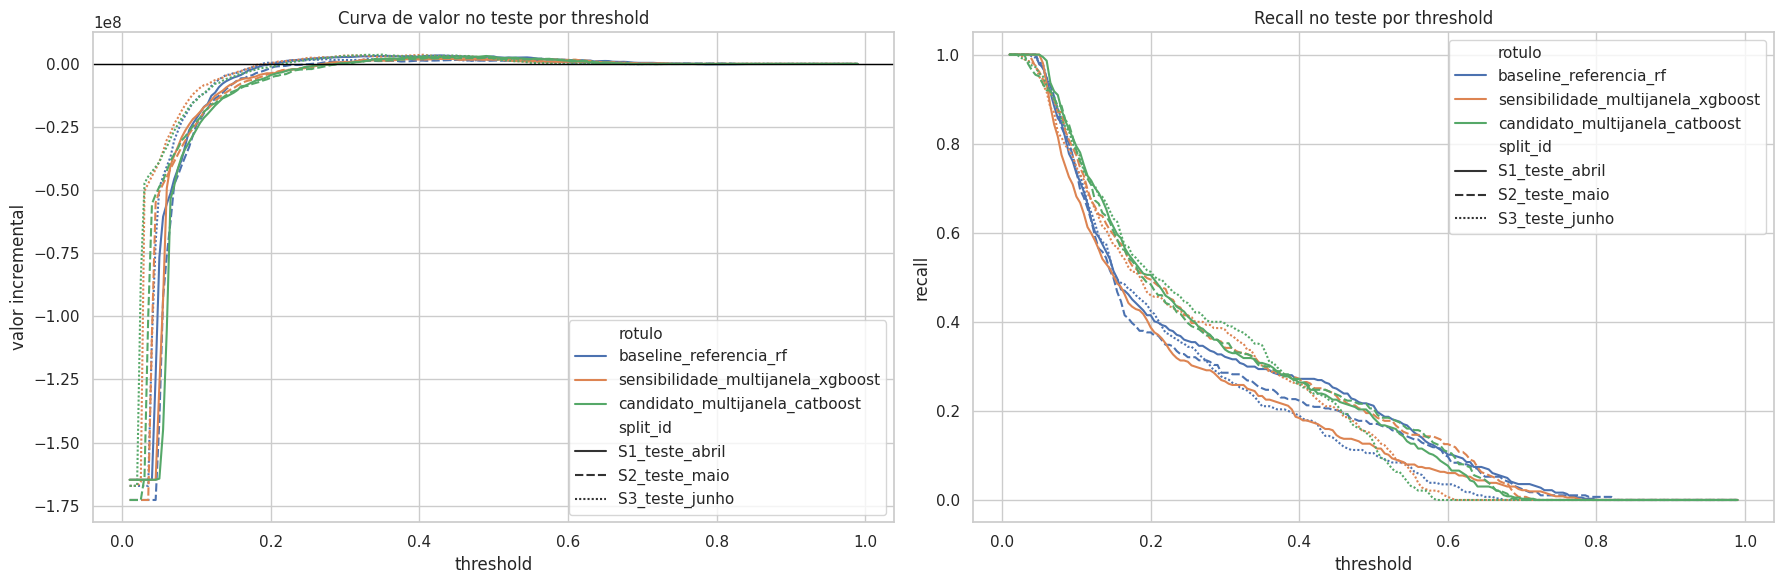

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plot_df = curves_focus[curves_focus["periodo"] == "teste"].copy()
sns.lineplot(data=plot_df, x="threshold", y="valor_incremental", hue="rotulo", style="split_id", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="Curva de valor no teste por threshold", ylabel="valor incremental")
sns.lineplot(data=plot_df, x="threshold", y="recall", hue="rotulo", style="split_id", ax=axes[1])
axes[1].set(title="Recall no teste por threshold")
plt.tight_layout()
plt.show()

## 6. Robustez a premissas econômicas

In [15]:
def value_with_assumptions(pred_df, threshold, assumptions):
    scored = pred_df.copy()
    econ_cols = [
        "p_acao_confirmada", "custo_intervencao_preditiva",
        "custo_manutencao_corretiva", "impacto_operacional_hora",
        "horas_parada_corretiva", "horas_parada_preditiva",
    ]
    scored = scored.drop(columns=[c for c in econ_cols if c in scored.columns])
    scored["predito"] = (scored["probabilidade"] >= threshold).astype("int8")
    scored["erro"] = np.select(
        [
            (scored["target"] == 1) & (scored["predito"] == 1),
            (scored["target"] == 0) & (scored["predito"] == 1),
            (scored["target"] == 1) & (scored["predito"] == 0),
            (scored["target"] == 0) & (scored["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    scored["tipo_economico"] = scored["Tipo"].map(normalize_tipo)
    econ = assumptions.rename(columns={"Tipo": "tipo_economico"})
    scored = scored.merge(econ, how="left", on="tipo_economico")
    no_action_cost = scored["p_acao_confirmada"] * (
        scored["custo_manutencao_corretiva"]
        + scored["impacto_operacional_hora"] * scored["horas_parada_corretiva"]
    )
    tp_action_cost = scored["custo_intervencao_preditiva"] + scored["p_acao_confirmada"] * (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )
    fp_action_cost = scored["custo_intervencao_preditiva"] + (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )
    value = np.select(
        [
            scored["erro"] == "TP",
            scored["erro"] == "FP",
            scored["erro"] == "FN",
            scored["erro"] == "TN",
        ],
        [
            no_action_cost - tp_action_cost,
            -fp_action_cost,
            0.0,
            0.0,
        ],
        default=np.nan,
    )
    return float(np.nansum(value))

scenarios = []
for name, p_mult, cost_mult, impact_mult in [
    ("baixo_p_baixo_impacto", 0.75, 1.00, 0.75),
    ("base", 1.00, 1.00, 1.00),
    ("alto_p_base", 1.15, 1.00, 1.00),
    ("alto_impacto", 1.00, 1.00, 1.25),
    ("intervencao_mais_cara", 1.00, 1.30, 1.00),
    ("conservador_duro", 0.75, 1.30, 0.75),
]:
    econ = economic_base.copy()
    econ["p_acao_confirmada"] = (econ["p_acao_confirmada"] * p_mult).clip(upper=1)
    econ["custo_intervencao_preditiva"] *= cost_mult
    econ["impacto_operacional_hora"] *= impact_mult
    scenarios.append((name, econ))

scenario_rows = []
for _, pair in candidate_pairs.iterrows():
    pred = predictions[
        (predictions["feature_set"] == pair["feature_set"])
        & (predictions["algoritmo"] == pair["algoritmo"])
    ].copy()
    if pred.empty:
        continue
    # Threshold operacional: melhor media do teste dentro da curva explicita do modelo.
    threshold_row = best_by_label[best_by_label["rotulo"] == pair["rotulo"]].iloc[0]
    threshold = float(threshold_row["threshold_melhor_media"])
    for split_id, split_pred in pred.groupby("split_id"):
        for scenario_name, econ in scenarios:
            scenario_rows.append({
                "rotulo": pair["rotulo"],
                "split_id": split_id,
                "threshold": threshold,
                "cenario": scenario_name,
                "valor": value_with_assumptions(split_pred, threshold, econ),
            })
scenario_results = pd.DataFrame(scenario_rows)
scenario_summary = (
    scenario_results.groupby(["rotulo", "cenario"])
    .agg(
        valor_medio=("valor", "mean"),
        valor_min=("valor", "min"),
        valor_max=("valor", "max"),
    )
    .reset_index()
    .sort_values(["cenario", "valor_medio"], ascending=[True, False])
)
display(scenario_summary)

,rotulo,cenario,valor_medio,valor_min,valor_max
6,candidato_multijanela_catboost,alto_impacto,3.292688e+06,2762062.500,3894875.00
12,sensibilidade_multijanela_xgboost,alto_impacto,2.844125e+06,2361937.500,3696250.00
0,baseline_referencia_rf,alto_impacto,2.696812e+06,1511250.000,3894812.50
7,candidato_multijanela_catboost,alto_p_base,3.833822e+06,3337305.000,4220030.00
13,sensibilidade_multijanela_xgboost,alto_p_base,3.278210e+06,2800935.000,3967300.00
1,baseline_referencia_rf,alto_p_base,3.263365e+06,2127300.000,4690045.00
8,candidato_multijanela_catboost,baixo_p_baixo_impacto,8.998260e+05,593253.125,1459643.75
14,sensibilidade_multijanela_xgboost,baixo_p_baixo_impacto,8.137562e+05,432809.375,1433312.50
2,baseline_referencia_rf,baixo_p_baixo_impacto,5.729573e+05,-61687.500,923593.75
9,candidato_multijanela_catboost,base,2.811367e+06,2360700.000,3312200.00


## 7. Separação por caminhões e escavadeiras

In [16]:
type_event_audit = (
    samples.groupby(["Tipo", samples["prediction_time"].dt.to_period("M")])
    .agg(
        amostras=("target", "size"),
        positivos=("target", "sum"),
        prevalencia=("target", "mean"),
        tags=("TAG", "nunique"),
    )
    .reset_index()
    .rename(columns={"prediction_time": "mes"})
)
display(type_event_audit)

candidate_type_summary = (
    curves_focus[curves_focus["periodo"] == "teste"]
    .merge(candidate_pairs, how="inner", on=["feature_set", "algoritmo", "rotulo"])
)

type_perf_rows = []
for _, pair in candidate_pairs.iterrows():
    pred = predictions[
        (predictions["feature_set"] == pair["feature_set"])
        & (predictions["algoritmo"] == pair["algoritmo"])
    ].copy()
    if pred.empty:
        continue
    threshold = float(best_by_label[best_by_label["rotulo"] == pair["rotulo"]].iloc[0]["threshold_melhor_media"])
    pred = economic_value_rows(pred, threshold)
    pred["rotulo"] = pair["rotulo"]
    type_perf_rows.append(pred)
type_perf = pd.concat(type_perf_rows, ignore_index=True)
type_perf_summary = (
    type_perf.groupby(["rotulo", "split_id", "Tipo"], dropna=False)
    .agg(
        amostras=("target", "size"),
        positivos=("target", "sum"),
        preditos=("predito", "sum"),
        TP=("erro", lambda x: (x == "TP").sum()),
        FP=("erro", lambda x: (x == "FP").sum()),
        FN=("erro", lambda x: (x == "FN").sum()),
        valor=("valor_incremental", "sum"),
    )
    .reset_index()
)
type_perf_summary["precision"] = type_perf_summary["TP"] / (type_perf_summary["TP"] + type_perf_summary["FP"]).replace(0, np.nan)
type_perf_summary["recall"] = type_perf_summary["TP"] / (type_perf_summary["TP"] + type_perf_summary["FN"]).replace(0, np.nan)
display(type_perf_summary)

,Tipo,mes,amostras,positivos,prevalencia,tags
0,Caminhao,2025-01,2700,462,0.171111,30
1,Caminhao,2025-02,2520,560,0.222222,30
2,Caminhao,2025-03,2790,510,0.182796,30
3,Caminhao,2025-04,2700,363,0.134444,30
4,Caminhao,2025-05,2700,280,0.103704,30
5,Caminhao,2025-06,2610,283,0.108429,30
6,Escavadeira,2025-01,450,7,0.015556,5
7,Escavadeira,2025-02,420,6,0.014286,5
8,Escavadeira,2025-03,465,1,0.002151,5
9,Escavadeira,2025-04,450,1,0.002222,5


,rotulo,split_id,Tipo,amostras,positivos,preditos,TP,FP,FN,valor,precision,recall
0,baseline_referencia_rf,S1_teste_abril,Caminhao,2700,363,218,99,119,264,3328300.0,0.454128,0.272727
1,baseline_referencia_rf,S1_teste_abril,Escavadeira,450,1,0,0,0,1,0.0,NaN,0.000000
2,baseline_referencia_rf,S2_teste_maio,Caminhao,2700,280,150,60,90,220,1302000.0,0.400000,0.214286
3,baseline_referencia_rf,S2_teste_maio,Escavadeira,450,7,0,0,0,7,0.0,NaN,0.000000
4,baseline_referencia_rf,S3_teste_junho,Caminhao,2610,283,95,50,45,233,2285000.0,0.526316,0.176678
5,baseline_referencia_rf,S3_teste_junho,Escavadeira,435,2,0,0,0,2,0.0,NaN,0.000000
6,candidato_multijanela_catboost,S1_teste_abril,Caminhao,2700,363,187,86,101,277,2986200.0,0.459893,0.236915
7,candidato_multijanela_catboost,S1_teste_abril,Escavadeira,450,1,1,0,1,1,-225000.0,0.000000,0.000000
8,candidato_multijanela_catboost,S2_teste_maio,Caminhao,2700,280,157,71,86,209,2360700.0,0.452229,0.253571
9,candidato_multijanela_catboost,S2_teste_maio,Escavadeira,450,7,0,0,0,7,0.0,NaN,0.000000


## 8. Leitura auditada

Registrar:

1. qual faixa de threshold é robusta para referência e CatBoost;
2. se o valor médio depende de um threshold pontual estreito;
3. se a ordem dos modelos muda sob cenários econômicos conservadores;
4. se há evidência para separar treinamento por tipo de equipamento;
5. se escavadeiras continuam sem suporte suficiente.